In [7]:
# 1. Install libraries and mount Google Drive
%pip install -q ultralytics

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
from ultralytics import YOLO
import torch

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# 2. Extract V1 dataset
import zipfile

zip_path = Path("/content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v1.zip")
dataset_path = Path("/content/pork_rasher_v1")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(dataset_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [9]:
# 3. Clean V1 dataset to prevent source-image leakage
import shutil

clean = Path("/content/pork_rasher_dataset_v1_clean")

shutil.rmtree(clean, ignore_errors=True)
shutil.copytree(dataset_path, clean)

def source_ids(split):
    return {
        p.name.split(".rf.")[0]
        for p in (clean / split / "images").glob("*.jpg")
    }

# Remove images sharing the same original source
for split, blocked in [
    ("train", source_ids("valid") | source_ids("test")),
    ("valid", source_ids("test"))
]:
    for image in (clean / split / "images").glob("*.jpg"):
        if image.name.split(".rf.")[0] in blocked:
            image.unlink()
            (clean / split / "labels" / f"{image.stem}.txt").unlink()

print("Dataset cleaning complete!")

Dataset cleaning complete!


In [10]:
# 4. Update data.yaml for cleaned V1 dataset
import yaml

yaml_path = clean / "data.yaml"
config = yaml.safe_load(yaml_path.read_text())

config.update({
    "path": str(clean),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images"
})

yaml_path.write_text(yaml.safe_dump(config))

# Display dataset sizes
for split in ["train", "valid", "test"]:
    images = list((clean / split / "images").glob("*.jpg"))
    print(f"{split}: {len(images)} images")

train: 1935 images
valid: 119 images
test: 80 images


In [11]:
# 5. Train Model A with learning rate 0.00125
runs = Path("/content/drive/MyDrive/MMA3001_Project/model_runs")

model_a = YOLO("yolov8n.pt")

results_a = model_a.train(
    data=str(clean / "data.yaml"),
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    seed=42,
    mosaic=0.0,
    optimizer="AdamW",
    lr0=0.00125,
    momentum=0.9,
    project=str(runs),
    name="v1_lr_00125"
)

print("Model A saved to:", results_a.save_dir)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pork_rasher_dataset_v1_clean/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00125, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=0.0, multi_scale=0.0, name=v1_lr_00125, nbs=64, nms=No

In [12]:
# 6. Train Model B with lower learning rate
model_b = YOLO("yolov8n.pt")

results_b = model_b.train(
    data=str(clean / "data.yaml"),
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    seed=42,
    mosaic=0.0,
    optimizer="AdamW",
    lr0=0.0005,
    momentum=0.9,
    project=str(runs),
    name="v1_lr_0005"
)

print("Model B saved to:", results_b.save_dir)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pork_rasher_dataset_v1_clean/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=0.0, multi_scale=0.0, name=v1_lr_0005, nbs=64, nms=None

In [14]:
# 7. Compare learning-rate experiments
import pandas as pd

models = {
    "Original No Mosaic": runs / "yolov8n_v1_no_mosaic/weights/best.pt",
    "LR 0.00125": runs / "v1_lr_00125/weights/best.pt",
    "LR 0.0005": runs / "v1_lr_0005/weights/best.pt"
}

comparison = []

for name, weights in models.items():
    model = YOLO(str(weights))

    metrics = model.val(
        data=str(clean / "data.yaml"),
        imgsz=640,
        split="val",
        conf=0.001,
        iou=0.7,
        device=0,
        plots=False
    )

    comparison.append({
        "Model": name,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map
    })

comparison_df = pd.DataFrame(comparison)
display(comparison_df.round(4))

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2859.5±802.4 MB/s, size: 75.1 KB)
val: Scanning /content/pork_rasher_dataset_v1_clean/valid/labels.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 33.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 6.9it/s 1.2s
                   all        119        154      0.641      0.623      0.695      0.321
            loose-meat          5          5      0.571        0.8      0.809      0.272
       packaging-error         35         57      0.465      0.263       0.36      0.114
          twisted-meat          4          5      0.787        0.6      0.777      0.362
              unsealed         84         87      0.741      0.828      0.835      0.536
Speed: 1.0ms preprocess, 4.1m

,Model,Precision,Recall,mAP50,mAP50-95
0,Original No Mosaic,0.6411,0.6227,0.6952,0.3209
1,LR 0.00125,0.6997,0.4950,0.5810,0.2906
2,LR 0.0005,0.7356,0.5562,0.6025,0.3354


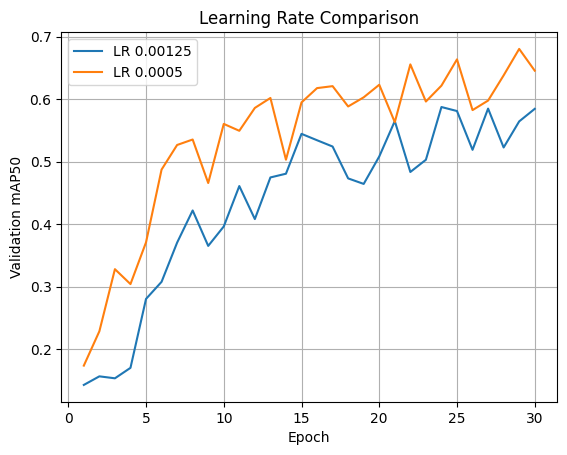

In [15]:
# 8. Compare validation mAP50 across training epochs
import pandas as pd
import matplotlib.pyplot as plt

for name, folder in [
    ("LR 0.00125", runs / "v1_lr_00125"),
    ("LR 0.0005", runs / "v1_lr_0005")
]:
    data = pd.read_csv(folder / "results.csv")
    data.columns = data.columns.str.strip()

    plt.plot(data["epoch"], data["metrics/mAP50(B)"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation mAP50")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid()
plt.show()

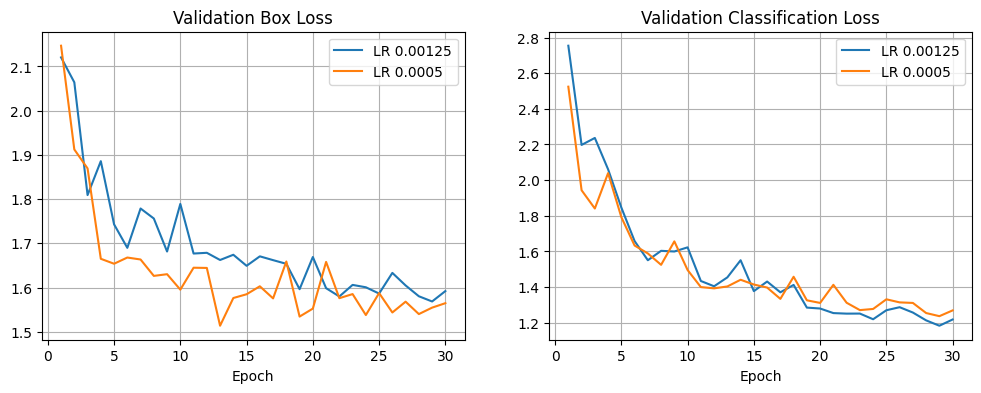

In [16]:
# 9. Compare validation box and classification losses
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, folder in [
    ("LR 0.00125", runs / "v1_lr_00125"),
    ("LR 0.0005", runs / "v1_lr_0005")
]:
    data = pd.read_csv(folder / "results.csv")
    data.columns = data.columns.str.strip()

    axes[0].plot(data["epoch"], data["val/box_loss"], label=name)
    axes[1].plot(data["epoch"], data["val/cls_loss"], label=name)

axes[0].set_title("Validation Box Loss")
axes[1].set_title("Validation Classification Loss")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid()

plt.show()

In [17]:
# 10. Train Model C for 50 epochs
model_c = YOLO("yolov8n.pt")

results_c = model_c.train(
    data=str(clean / "data.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    seed=42,
    mosaic=0.0,
    optimizer="AdamW",
    lr0=0.0005,
    momentum=0.9,
    project=str(runs),
    name="v1_lr_0005_50epochs"
)

print("Model C saved to:", results_c.save_dir)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pork_rasher_dataset_v1_clean/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=0.0, multi_scale=0.0, name=v1_lr_0005_50epochs, nbs=64,

In [18]:
# 11. Add 50-epoch model to comparison
model_c = YOLO(str(runs / "v1_lr_0005_50epochs/weights/best.pt"))

metrics_c = model_c.val(
    data=str(clean / "data.yaml"),
    imgsz=640,
    split="val",
    conf=0.001,
    iou=0.7,
    device=0,
    plots=False
)

comparison_df.loc[len(comparison_df)] = {
    "Model": "LR 0.0005 (50 epochs)",
    "Precision": metrics_c.box.mp,
    "Recall": metrics_c.box.mr,
    "mAP50": metrics_c.box.map50,
    "mAP50-95": metrics_c.box.map
}

display(comparison_df.round(4))

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2586.3±782.6 MB/s, size: 75.1 KB)
val: Scanning /content/pork_rasher_dataset_v1_clean/valid/labels.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 35.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 7.0it/s 1.1s
                   all        119        154      0.653      0.571      0.636      0.314
            loose-meat          5          5          1      0.953      0.995      0.441
       packaging-error         35         57      0.529      0.336      0.351      0.108
          twisted-meat          4          5      0.239        0.2      0.353      0.193
              unsealed         84         87      0.844      0.793      0.844      0.515
Speed: 0.9ms preprocess, 3.2m

,Model,Precision,Recall,mAP50,mAP50-95
0,Original No Mosaic,0.6411,0.6227,0.6952,0.3209
1,LR 0.00125,0.6997,0.4950,0.5810,0.2906
2,LR 0.0005,0.7356,0.5562,0.6025,0.3354
3,LR 0.0005 (50 epochs),0.6532,0.5705,0.6361,0.3143


In [19]:
# 12. Compare performance at different epochs
data = pd.read_csv(runs / "v1_lr_0005_50epochs/results.csv")
data.columns = data.columns.str.strip()

comparison_epochs = data[data["epoch"].isin([30, 40, 50])]

display(comparison_epochs[
    ["epoch", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]
].round(4))

,epoch,metrics/mAP50(B),metrics/mAP50-95(B)
29,30,0.5843,0.2868
39,40,0.5882,0.2666
49,50,0.6150,0.2862
